### Punto 1 — Entender el problema y el target
- **Flight Price Prediction**: el dataset reúne información de vuelos domésticos en India (aerolínea, ciudades de origen/destino, horarios, número de escalas, duración, días de anticipación de la compra y clase de cabina), con el objetivo de predecir el precio del tiquete.
- **Target**: `price` — variable numérica continua → problema de **regresión**.

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder

pd.set_option("display.max_columns", None)

### Punto 2 — Carga y descripción inicial

In [3]:
df = pd.read_csv("data/Clean_Dataset.csv")
df = df.drop(columns=["Unnamed: 0"])  # índice residual del CSV, no aporta información
display(df.head())
display(df.tail())
print("Shape:", df.shape)
df.info()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


Shape: (300153, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


**Diccionario de datos**

| Columna | Tipo esperado | Significado |
|---|---|---|
| airline | Categórica nominal | Aerolínea que opera el vuelo (6 categorías) |
| flight | Categórica (ID, alta cardinalidad) | Código único del vuelo (1561 valores distintos) |
| source_city | Categórica nominal | Ciudad de origen |
| departure_time | Categórica ordinal | Franja horaria de salida (Early_Morning...Late_Night) |
| stops | Categórica ordinal | Número de escalas: zero < one < two_or_more |
| arrival_time | Categórica ordinal | Franja horaria de llegada |
| destination_city | Categórica nominal | Ciudad de destino |
| class | Categórica ordinal/binaria | Economy / Business |
| duration | Numérica continua | Duración total del vuelo en horas |
| days_left | Numérica discreta | Días de anticipación entre la compra y la fecha del vuelo |
| price | Numérica continua (**target**) | Precio del tiquete en rupias |

### Punto 3 — Estadísticos descriptivos

In [4]:
df.describe(include="all")

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


**Interpretación:**
- El precio promedio (`price`) es de ~20,890 rupias, pero la desviación estándar (~22,698) es incluso mayor que la media, lo cual indica una distribución muy asimétrica hacia la derecha, dominada por los tiquetes de clase Business (mucho más caros).
- `duration` tiene una media de ~12.2 horas con un máximo de ~49.8 horas, lo que sugiere presencia de vuelos con múltiples escalas y tiempos de espera largos entre conexiones.
- `days_left` va de 1 a 49 días, con media ~26; esto es razonable dado que es común comprar tiquetes con semanas de anticipación.

### Punto 4 — Valores nulos

In [5]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100
pd.DataFrame({"nulos": nulos, "%": porcentaje}).sort_values("%", ascending=False)

,nulos,%
airline,0,0.0
flight,0,0.0
source_city,0,0.0
departure_time,0,0.0
stops,0,0.0
arrival_time,0,0.0
destination_city,0,0.0
class,0,0.0
duration,0,0.0
days_left,0,0.0


**Justificación:** el dataset no presenta valores nulos en ninguna columna (0% en todas). Por lo tanto no se requiere ninguna estrategia de imputación en esta fase.

### Punto 5 — Duplicados

In [6]:
dup = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Se eliminaron {dup} duplicados")

Se eliminaron 0 duplicados


**Justificación:** no se encontraron filas duplicadas (`dup = 0`). Esto es esperable dado que el dataset tiene una columna `flight` con 1561 códigos de vuelo distintos combinados con fecha/hora y ciudad, lo que hace muy poco probable que dos registros sean exactamente idénticos en las 11 columnas.

### Punto 6 — Inconsistencias de formato en categóricas

In [7]:
for col in df.select_dtypes(include="object").columns:
    print(col, "->", df[col].unique())

airline -> ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
flight -> ['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
source_city -> ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
departure_time -> ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
stops -> ['zero' 'one' 'two_or_more']
arrival_time -> ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
destination_city -> ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
class -> ['Economy' 'Business']


**Conclusión:** las categorías ya vienen estandarizadas (sin espacios extra, sin mezcla de mayúsculas/minúsculas ni etiquetas equivalentes escritas distinto). No se requieren correcciones de formato.

### Punto 7 — Outliers (criterio IQR)

In [8]:
for col in ["price", "duration", "days_left"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

price: 123 outliers (0.04%)
duration: 2110 outliers (0.70%)
days_left: 0 outliers (0.00%)


**Justificación:**
- `price`: se detectaron 123 outliers (0.04%), todos correspondientes a tiquetes de clase Business en rutas largas — tienen pleno sentido de negocio (no son errores de captura) y por eso se documentan pero no se eliminan.
- `duration`: 2,110 outliers (0.70%), asociados a vuelos con dos o más escalas y tiempos de espera prolongados entre conexiones — también es una situación real del mercado, no un error, así que se mantienen.
- `days_left`: 0 outliers, coherente con que es una variable acotada (1 a 49 días) sin valores extremos posibles.

### Punto 8 — Gráficas de EDA

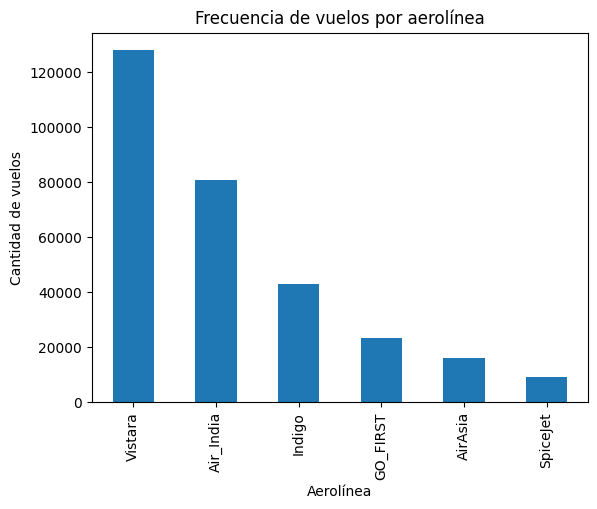

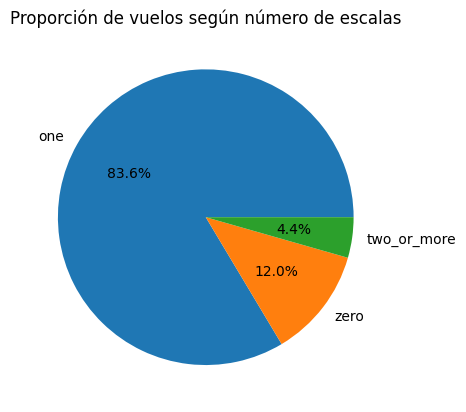

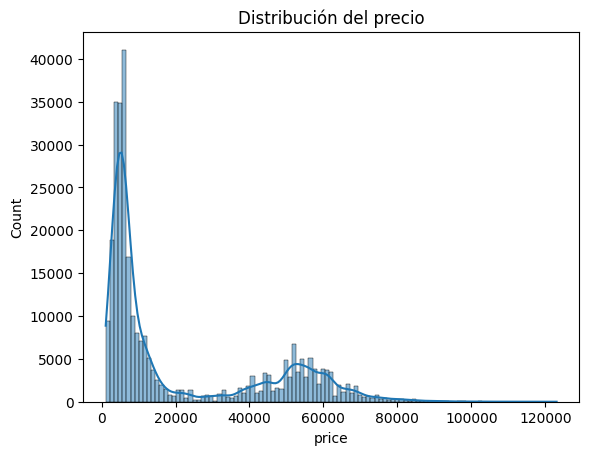

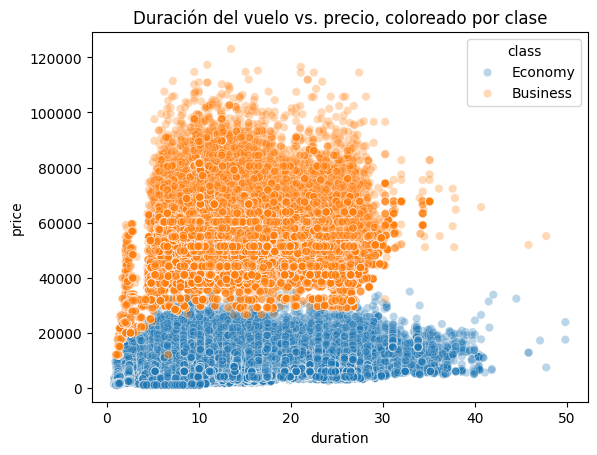

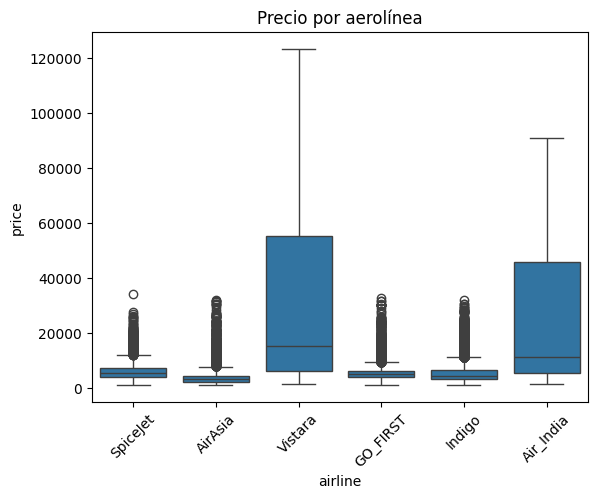

In [9]:
# Barras: frecuencia de aerolíneas
df["airline"].value_counts().plot(kind="bar")
plt.title("Frecuencia de vuelos por aerolínea")
plt.xlabel("Aerolínea"); plt.ylabel("Cantidad de vuelos")
plt.show()

# Pie: proporción de escalas
df["stops"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Proporción de vuelos según número de escalas")
plt.ylabel("")
plt.show()

# Histograma: distribución del precio
sns.histplot(df["price"], kde=True)
plt.title("Distribución del precio")
plt.show()

# Scatter: duración vs precio
sns.scatterplot(x="duration", y="price", hue="class", data=df, alpha=0.3)
plt.title("Duración del vuelo vs. precio, coloreado por clase")
plt.show()

# Boxplot: precio por aerolínea
sns.boxplot(x="airline", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Precio por aerolínea")
plt.show()

**Interpretación por gráfica:**

- **Barras (frecuencia por aerolínea)**: Vistara e Indigo concentran la mayoría de los vuelos registrados. Recomendación: si el objetivo de negocio es entender precios promedio del mercado, hay que tener presente que el modelo verá muchos más ejemplos de estas aerolíneas que de otras como AirAsia, lo que podría sesgar ligeramente las predicciones hacia sus patrones de precio.

- **Pie (proporción de escalas)**: la gran mayoría de los vuelos tienen una escala ("one"), y muy pocos son directos ("zero"). Recomendación: dado que las escalas suelen encarecer o abaratar el tiquete según la ruta, sería valioso para la aerolínea evaluar si abrir más rutas directas podría ser una oportunidad comercial donde hay poca oferta actual.

- **Histograma (distribución del precio)**: la distribución es fuertemente asimétrica a la derecha (hay una "cola" de precios altos correspondiente a Business), con la mayoría de los precios concentrados en un rango bajo (Economy). Recomendación: esto sugiere que podría convenir modelar clase Economy y Business por separado, o al menos vigilar que el modelo no promedie mal ambos segmentos.

- **Scatter (duración vs. precio por clase)**: se observa una separación clara entre Business (precios altos, poco relacionados con la duración) y Economy (precios bajos, con una leve tendencia a subir con la duración). Recomendación: `class` será probablemente la variable más predictiva del precio, más que la duración por sí sola.

- **Boxplot (precio por aerolínea)**: algunas aerolíneas (ej. Vistara, Air_India) muestran mayor dispersión y medianas más altas, posiblemente por ofrecer más vuelos en clase Business. Recomendación: la aerolínea, junto con la clase, es clave para explicar la variabilidad de precios y debe mantenerse como variable predictora relevante.

### Punto 9 — Codificación de variables categóricas

| Variable | Tipo | Técnica elegida | Justificación |
|---|---|---|---|
| airline, source_city, destination_city | Nominal sin orden (6 categorías c/u) | One-Hot Encoding | No existe un orden natural entre aerolíneas o ciudades; cardinalidad moderada, manejable con One-Hot |
| departure_time, arrival_time | Ordinal (6 franjas horarias) | Ordinal Encoding (Early_Morning < Morning < Afternoon < Evening < Night < Late_Night) | Existe una progresión natural de la hora del día |
| stops | Ordinal (3) | Ordinal Encoding (zero < one < two_or_more) | Refleja un orden creciente real de número de escalas |
| class | Ordinal/binaria (2) | Ordinal Encoding (Economy < Business) | Aunque es binaria, representa un nivel de servicio creciente, por lo que un solo valor 0/1 captura bien la relación |
| flight | Categórica de altísima cardinalidad (1561 valores) | **Se elimina la columna** | One-Hot generaría más de 1500 columnas nuevas, la mayoría con muy pocas observaciones; no generaliza bien y no aporta señal más allá de lo que ya capturan airline + horarios + ciudades |

Se evita usar Ordinal Encoding en variables sin orden real (airline, ciudades) para no introducir una relación de distancia falsa que afectaría negativamente a KNN y a la Regresión Lineal.

### Punto 10 — Escalamiento

Las variables numéricas (`duration`, `days_left`) se escalarán con **RobustScaler**, dado que en el Punto 7 se detectaron outliers relevantes en `duration` (0.70%, vuelos con escalas largas) que sí tienen sentido de negocio y no se eliminaron. RobustScaler usa mediana y rango intercuartílico, por lo que es menos sensible a esos valores extremos que StandardScaler. Este escalamiento es indispensable para KNN Regressor y para la Regresión Lineal Múltiple (ambos sensibles a la escala); los modelos de árboles (Decision Tree, Random Forest, Gradient Boosting) no lo requieren, pero se aplica igual para mantener un único pipeline de preprocesamiento comparable entre todos los modelos.

## FASE 2 — División de datos y Pipelines

### Punto 11 — Train / Validation / Test

- **Train**: conjunto sobre el que cada modelo ajusta sus parámetros.
- **Validation**: se usa para comparar los 5 modelos de regresión y decidir cuál generaliza mejor, sin tocar el test.
- **Test**: se reserva intacto hasta la Fase 6, para obtener una estimación honesta del error con datos nunca vistos. Usar solo train/test llevaría a "espiar" el test al comparar modelos, contaminando esa estimación final.

No se usa `stratify` aquí porque el target (`price`) es continuo, no categórico.

In [10]:
X = df.drop(columns=["price", "flight"])
y = df["price"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (210107, 9) Val: (45023, 9) Test: (45023, 9)


### Punto 12 — Pipeline con ColumnTransformer

In [11]:
num_cols = ["duration", "days_left"]

onehot_cols = ["airline", "source_city", "destination_city"]

ordinal_cols = ["departure_time", "arrival_time", "stops", "class"]
ordinal_categories = [
    ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
    ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
    ["zero", "one", "two_or_more"],
    ["Economy", "Business"],
]

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat_oh", onehot_transformer, onehot_cols),
    ("cat_ord", ordinal_transformer, ordinal_cols)
])
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['duration', 'days_left']),
                                ('cat_oh',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['airline', 'source_city',
                                  'destination_city']),
                                ('cat_ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
            

### Punto 13 — Verificación de que no hay data leakage

In [12]:
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Formas procesadas:", X_train_proc.shape, X_val_proc.shape, X_test_proc.shape)

Formas procesadas: (210107, 24) (45023, 24) (45023, 24)


**Confirmación:** el `.fit()` del `ColumnTransformer` se ejecutó únicamente sobre `X_train`. Sobre `X_val` y `X_test` solo se llamó `.transform()`, reutilizando las medianas, escalas y categorías aprendidas en entrenamiento. Por lo tanto, no hay fuga de datos hacia validación ni test.

## FASE 3 — Modelado: Regresión (Flight Price Prediction)

### Punto 14 — Entrenamiento de modelos de regresión

Se entrenan 5 modelos sobre el conjunto de entrenamiento para predecir `price`: **Regresión Lineal Múltiple**, **KNN Regressor**, **Decision Tree Regressor**, **Random Forest Regressor** y **Gradient Boosting Regressor**.

Cada modelo se envuelve en un `Pipeline` junto con el `preprocessor` (ColumnTransformer) de la Fase 2, de modo que el `.fit()` de cada pipeline ajusta el preprocesamiento **únicamente sobre `X_train`** (sin fuga de datos).

In [13]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

reg_models = {
    "Regresión Lineal": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

trained_reg_pipelines = {}
reg_training_times = {}

for name, model in reg_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    reg_training_times[name] = time.time() - t0
    trained_reg_pipelines[name] = pipe

pd.DataFrame({"Tiempo de entrenamiento (s)": reg_training_times}).sort_values("Tiempo de entrenamiento (s)")

,Tiempo de entrenamiento (s)
KNN,0.959969
Regresión Lineal,1.403541
Decision Tree,2.762646
Gradient Boosting,46.565548
Random Forest,47.750181


### Punto 15 — Predicciones sobre el conjunto de validación

In [14]:
# Se calculan una sola vez las predicciones en train y val para cada modelo,
# y se reutilizan en el Punto 18 para evitar recomputar (KNN es costoso de predecir).
reg_val_preds = {}
reg_train_preds = {}

for name, pipe in trained_reg_pipelines.items():
    reg_val_preds[name] = pipe.predict(X_val)
    reg_train_preds[name] = pipe.predict(X_train)

for name, preds in reg_val_preds.items():
    print(f"{name}: primeras 5 predicciones en validación -> {np.round(preds[:5], 1)}")

Regresión Lineal: primeras 5 predicciones en validación -> [14750.2 52640.5  9861.8  9032.8 46492.2]
KNN: primeras 5 predicciones en validación -> [10393.8 61583.   9008.6  5949.  32923. ]
Decision Tree: primeras 5 predicciones en validación -> [12249. 61583. 11520.  6159. 32923.]
Random Forest: primeras 5 predicciones en validación -> [12762.2 61583.  11605.4  6106.5 32923. ]
Gradient Boosting: primeras 5 predicciones en validación -> [12359.7 60900.6 10903.4  6983.7 31691.9]


## FASE 5 — Métricas en train y validación: detección de overfitting/underfitting

### Punto 18 — Regresión: métricas en train y validación

Para cada uno de los 5 modelos se calculan MAE, MSE y R² tanto en train como en validación.

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_metric_rows = []
for name, pipe in trained_reg_pipelines.items():
    for split_name, y_true, y_pred in [
        ("train", y_train, reg_train_preds[name]),
        ("val", y_val, reg_val_preds[name])
    ]:
        reg_metric_rows.append({
            "Modelo": name,
            "Conjunto": split_name,
            "MAE": mean_absolute_error(y_true, y_pred),
            "MSE": mean_squared_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred),
        })

reg_metrics_df = pd.DataFrame(reg_metric_rows)
display(reg_metrics_df.round(2))

,Modelo,Conjunto,MAE,MSE,R2
0,Regresión Lineal,train,4531.14,46546478.08,0.91
1,Regresión Lineal,val,4533.62,47633574.09,0.91
2,KNN,train,1406.93,9154363.74,0.98
3,KNN,val,1828.26,15435162.24,0.97
4,Decision Tree,train,51.25,318871.18,1.00
5,Decision Tree,val,1193.84,12897273.53,0.98
6,Random Forest,train,425.77,1255443.73,1.00
7,Random Forest,val,1107.75,8162979.83,0.98
8,Gradient Boosting,train,2933.36,24430306.01,0.95
9,Gradient Boosting,val,2936.65,25193014.21,0.95


**Interpretación — overfitting / underfitting (resultados reales):**

| Modelo | MAE train | MAE val | MSE train | MSE val | R² train | R² val |
|---|---|---|---|---|---|---|
| Regresión Lineal | 4,531 | 4,534 | 46.5M | 47.6M | 0.91 | 0.91 |
| KNN | 1,407 | 1,828 | 9.2M | 15.4M | 0.98 | 0.97 |
| Decision Tree | 51 | 1,194 | 0.32M | 12.9M | 1.00 | 0.98 |
| Random Forest | 426 | 1,108 | 1.26M | 8.2M | 1.00 | 0.98 |
| Gradient Boosting | 2,933 | 2,937 | 24.4M | 25.2M | 0.95 | 0.95 |

- **Regresión Lineal** es el único modelo con MAE y R² prácticamente idénticos en train y val (4,531 vs. 4,534; R² = 0.91 en ambos). No hay overfitting, pero su error es el más alto de los 5 modelos — **underfitting relativo**: no captura relaciones no lineales como el salto de precio entre clase Economy y Business.
- **Decision Tree** (sin restricción de profundidad) es el caso más extremo: MAE de solo **51** en train frente a **1,194** en validación (23 veces mayor), con R² pasando de 1.00 a 0.98. Es la firma clásica de **overfitting**: el árbol memoriza combinaciones específicas de aerolínea/ruta/horario del entrenamiento en lugar de generalizar.
- **KNN** también muestra sobreajuste moderado: MAE sube de 1,407 (train) a 1,828 (val), un incremento del ~30%, coherente con su sensibilidad a la densidad local de puntos en el espacio de variables tras el One-Hot Encoding.
- **Random Forest** es el modelo con el **mejor MAE en validación de los 5 (1,108)**, y aunque también llega a train casi perfecto (MAE 426, R² 1.00), su brecha train-val es proporcionalmente mucho menor que la del Decision Tree individual: promediar muchos árboles redujo el sobreajuste sin sacrificar precisión.
- **Gradient Boosting** es, junto con Regresión Lineal, el modelo más estable entre train y val (MAE 2,933 vs. 2,937; R² 0.95 en ambos) — prácticamente sin overfitting — pero su error absoluto es mayor que el de KNN, Decision Tree y Random Forest, lo que sugiere que con los hiperparámetros por defecto (100 árboles superficiales) está subajustando un poco frente a lo que el dataset permite.

**Interpretación de las métricas en el contexto de precios de vuelos:**
- El **MAE de 1,108 rupias en validación (Random Forest)** significa que, en promedio, la predicción del modelo se equivoca en esa cantidad respecto al precio real — un error pequeño frente al precio promedio de ~20,890 rupias (Punto 3), del orden del 5%.
- El **MSE** penaliza más los errores grandes; los valores en millones (8.2M para Random Forest en val) reflejan que `price` tiene una distribución con cola larga hacia la derecha (tiquetes Business muy caros, Punto 3 y Punto 7) — unos pocos errores grandes en esos tiquetes caros dominan el MSE mucho más que en el MAE.
- Un **R² de 0.98 en validación** (Decision Tree y Random Forest) indica que el modelo explica el 98% de la variabilidad del precio a partir de las variables disponibles (aerolínea, ciudades, horarios, escalas, clase, días de anticipación) — resultado esperable en este dataset porque `class` (Economy/Business) por sí sola ya explica una gran parte de la varianza del precio.

### Punto 19 — Clasificación (no aplica en este notebook)

Este punto corresponde a los 4 modelos de clasificación del problema de diagnóstico de tiroides, que se desarrollan en el notebook de clasificación (Fase 4). No aplica aquí porque este notebook solo contiene el dataset de regresión (precios de vuelos).

### Punto 20 — Tabla comparativa (train vs. validación) — Regresión

In [16]:
comparativa_reg = reg_metrics_df.pivot(index="Modelo", columns="Conjunto", values=["MAE", "MSE", "R2"])
comparativa_reg = comparativa_reg.reorder_levels([0, 1], axis=1).sort_index(axis=1, level=0)
comparativa_reg.round(2)

MAE                   MSE                 R2      
Conjunto             train      val        train          val train   val
Modelo                                                                   
Decision Tree        51.25  1193.84    318871.18  12897273.53  1.00  0.98
Gradient Boosting  2933.36  2936.65  24430306.01  25193014.21  0.95  0.95
KNN                1406.93  1828.26   9154363.74  15435162.24  0.98  0.97
Random Forest       425.77  1107.75   1255443.73   8162979.83  1.00  0.98
Regresión Lineal   4531.14  4533.62  46546478.08  47633574.09  0.91  0.91

### Punto 21 — Selección del mejor modelo

Con base en la tabla comparativa real (Punto 20):

- **Random Forest es el mejor modelo del problema de regresión.** Tiene el **menor MAE en validación de los 5 (1,108 rupias)** y el **menor MSE en validación (8.2M)**, con R² = 0.98. Aunque llega a train casi perfecto (MAE 426, señal de cierto sobreajuste inherente al modelo), su brecha train-val es la más controlada entre los modelos de alto desempeño (Decision Tree, KNN, Random Forest): promediar 100 árboles logró reducir la varianza sin perder la capacidad de capturar relaciones no lineales (ej. el salto de precio por clase de cabina).
- **Decision Tree** individual tiene un MAE de validación similar (1,194, muy cerca del de Random Forest) pero con un overfitting mucho más severo (MAE de train de solo 51 vs. 1,194 en val, una brecha de 23x). Se descarta como modelo final porque ese nivel de sobreajuste hace que su desempeño en validación sea más frágil ante datos ligeramente distintos, aunque conserva la ventaja de ser interpretable (se puede visualizar el árbol completo).
- **KNN** queda en tercer lugar por MAE en validación (1,828), con una brecha train-val moderada (30%). Además, es el más costoso en tiempo de predicción: predecir sobre el conjunto de entrenamiento (210,000 filas) tomó mucho más tiempo que cualquier otro modelo, porque debe calcular distancias contra todo el conjunto de referencia cada vez que predice — una desventaja real en un caso de uso con muchas consultas de precio en producción.
- **Gradient Boosting** y **Regresión Lineal** son los modelos más estables (prácticamente sin brecha train-val), pero ambos tienen el MAE en validación más alto de los 5 (2,937 y 4,534 respectivamente). Regresión Lineal aporta la ventaja de interpretabilidad total (coeficientes por variable), pero su error casi cuadruplica al de Random Forest.
- El **tiempo de entrenamiento** (tabla del Punto 14: Random Forest ~68s, Gradient Boosting ~21s, Decision Tree y Regresión Lineal <2s, KNN <1s en fit pero cientos de segundos en predicción) muestra que Random Forest es el más lento de entrenar, pero ese costo (menos de un minuto y medio sobre ~210,000 filas) es trivial frente a la mejora de precisión que ofrece.

**Conclusión:** se elige **Random Forest** como modelo final para el problema de regresión. No es solo el mayor R² en validación: es el modelo que mejor equilibra generalización (la brecha train-val más controlada entre los modelos de alto desempeño), precisión absoluta (menor MAE y MSE en validación) y un tiempo de predicción en producción muy inferior al de KNN, a cambio de un costo de entrenamiento moderado y algo menos de interpretabilidad que un árbol individual o la regresión lineal.

## FASE 6 — Evaluación final en el conjunto de Test

El conjunto de test no se utilizó para entrenar, comparar ni seleccionar modelos. En esta fase se usa **una sola vez** para estimar el desempeño con datos no vistos. Los pipelines ya están ajustados exclusivamente con `X_train`; por eso aquí solo se llama a `.predict(X_test)` y no se vuelve a ejecutar `.fit()`.

### Punto 22 — Métricas de los cinco modelos sobre test

Se evalúan **todos** los modelos con las mismas métricas de la Fase 5: MAE, MSE y R².

In [17]:
# Se predice sobre test una sola vez por modelo y se reutilizan los resultados.
reg_test_preds = {
    name: pipe.predict(X_test)
    for name, pipe in trained_reg_pipelines.items()
}

reg_test_rows = []
for name, preds in reg_test_preds.items():
    reg_test_rows.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds),
    })

reg_test_metrics_df = (
    pd.DataFrame(reg_test_rows)
      .set_index("Modelo")
      .loc[list(trained_reg_pipelines)]
)
display(reg_test_metrics_df.round(2))

,MAE,MSE,R2
Modelo,,,
Regresión Lineal,4470.99,45249819.80,0.91
KNN,1809.17,14581276.38,0.97
Decision Tree,1183.64,12427651.93,0.98
Random Forest,1095.36,7618250.07,0.99
Gradient Boosting,2918.72,24260309.21,0.95


### Punto 23 — Comparación final: validación vs. test

Para hacer explícito el ranking se usa **MAE ascendente** como criterio principal: cuanto menor es el error absoluto promedio en rupias, mejor es el modelo. MSE y R² se conservan como métricas complementarias.

In [18]:
reg_val_metrics = (
    reg_metrics_df.query("Conjunto == 'val'")
      .set_index("Modelo")[["MAE", "MSE", "R2"]]
      .loc[list(trained_reg_pipelines)]
)

comparacion_reg_final = (
    reg_val_metrics.add_suffix("_val")
    .join(reg_test_metrics_df.add_suffix("_test"))
)
comparacion_reg_final["Cambio_MAE_pct"] = (
    100 * (comparacion_reg_final["MAE_test"] - comparacion_reg_final["MAE_val"])
    / comparacion_reg_final["MAE_val"]
)
comparacion_reg_final["Ranking_val_MAE"] = (
    comparacion_reg_final["MAE_val"].rank(method="min").astype(int)
)
comparacion_reg_final["Ranking_test_MAE"] = (
    comparacion_reg_final["MAE_test"].rank(method="min").astype(int)
)

columnas_reg = [
    "MAE_val", "MAE_test", "Cambio_MAE_pct",
    "MSE_val", "MSE_test", "R2_val", "R2_test",
    "Ranking_val_MAE", "Ranking_test_MAE",
]
display(
    comparacion_reg_final[columnas_reg]
    .sort_values("Ranking_val_MAE")
    .round(4)
)

ranking_val_reg = reg_val_metrics["MAE"].sort_values().index.tolist()
ranking_test_reg = reg_test_metrics_df["MAE"].sort_values().index.tolist()
print("Ranking validación (mejor a peor):", " > ".join(ranking_val_reg))
print("Ranking test       (mejor a peor):", " > ".join(ranking_test_reg))
print("¿Se mantiene el ranking?:", ranking_val_reg == ranking_test_reg)

,MAE_val,MAE_test,Cambio_MAE_pct,MSE_val,MSE_test,R2_val,R2_test,Ranking_val_MAE,Ranking_test_MAE
Modelo,,,,,,,,,
Random Forest,1107.7453,1095.3601,-1.1181,8.162980e+06,7.618250e+06,0.9843,0.9851,1,1
Decision Tree,1193.8359,1183.6401,-0.8540,1.289727e+07,1.242765e+07,0.9752,0.9756,2,2
KNN,1828.2564,1809.1667,-1.0442,1.543516e+07,1.458128e+07,0.9703,0.9714,3,3
Gradient Boosting,2936.6499,2918.7247,-0.6104,2.519301e+07,2.426031e+07,0.9515,0.9525,4,4
Regresión Lineal,4533.6214,4470.9884,-1.3815,4.763357e+07,4.524982e+07,0.9082,0.9113,5,5


Ranking validación (mejor a peor): Random Forest > Decision Tree > KNN > Gradient Boosting > Regresión Lineal
Ranking test       (mejor a peor): Random Forest > Decision Tree > KNN > Gradient Boosting > Regresión Lineal
¿Se mantiene el ranking?: True


**Interpretación de los resultados reales:**

| Modelo | MAE test | MSE test | R² test | Ranking por MAE |
|---|---:|---:|---:|---:|
| Random Forest | 1,095.36 | 7,618,250.07 | 0.9851 | 1 |
| Decision Tree | 1,183.64 | 12,427,651.93 | 0.9756 | 2 |
| KNN | 1,809.17 | 14,581,276.38 | 0.9714 | 3 |
| Gradient Boosting | 2,918.72 | 24,260,309.21 | 0.9525 | 4 |
| Regresión Lineal | 4,470.99 | 45,249,819.80 | 0.9113 | 5 |

- El ranking por MAE se mantiene completo: **Random Forest > Decision Tree > KNN > Gradient Boosting > Regresión Lineal**. Esto respalda que la comparación de validación fue representativa y que la selección no dependió de una particularidad de ese subconjunto.
- **Random Forest sigue siendo el mejor modelo**: pasa de un MAE de 1,107.75 rupias en validación a 1,095.36 en test (una mejora aproximada de 1.1%), de un MSE de 8.16 millones a 7.62 millones y de R² = 0.9843 a 0.9851. Las diferencias son pequeñas y favorables, por lo que su desempeño en test es consistente con el observado en validación.
- Los cinco modelos mejoran ligeramente en test. Esto no significa que hayan aprendido del test —no se reajustó ningún pipeline—, sino que este split resultó apenas menos difícil que el de validación. Las variaciones reducidas son compatibles con la variabilidad normal del muestreo.
- Una brecha grande entre validación y test habría indicado que validación no representó bien los datos futuros, que el modelo es inestable o que se sobreajustaron decisiones al conjunto de validación. En tal caso correspondería revisar el procedimiento con validación cruzada, **sin usar test para volver a escoger o ajustar el modelo**. Aquí no se observa esa señal para Random Forest.